## 10% Strain Stress Curve

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math
import re

# To avoid displaying FutureWarnings from pandas/numpy
warnings.filterwarnings('ignore', category=FutureWarning)

# Allow to show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv("60-100.csv", header=[0,1,2])

df.head(10)

,60R1,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,60R2,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,60R3,Unnamed: 11_level_0,Unnamed: 12_level_0,Unnamed: 13_level_0,Unnamed: 14_level_0,60R4,Unnamed: 16_level_0,Unnamed: 17_level_0,Unnamed: 18_level_0,Unnamed: 19_level_0,60R5,Unnamed: 21_level_0,Unnamed: 22_level_0,Unnamed: 23_level_0,Unnamed: 24_level_0,60R6,Unnamed: 26_level_0,Unnamed: 27_level_0,Unnamed: 28_level_0,Unnamed: 29_level_0,60R7,Unnamed: 31_level_0,Unnamed: 32_level_0,Unnamed: 33_level_0,Unnamed: 34_level_0,60R8,Unnamed: 36_level_0,Unnamed: 37_level_0,Unnamed: 38_level_0,Unnamed: 39_level_0,60R9,Unnamed: 41_level_0,Unnamed: 42_level_0,Unnamed: 43_level_0,Unnamed: 44_level_0,60R10,Unnamed: 46_level_0,Unnamed: 47_level_0,Unnamed: 48_level_0,Unnamed: 49_level_0,70R1,Unnamed: 51_level_0,Unnamed: 52_level_0,Unnamed: 53_level_0,Unnamed: 54_level_0,70R2,Unnamed: 56_level_0,Unnamed: 57_level_0,Unnamed: 58_level_0,Unnamed: 59_level_0,70R3,Unnamed: 61_level_0,Unnamed: 62_level_0,Unnamed: 63_level_0,Unnamed: 64_level_0,70R4,Unnamed: 66_level_0,Unnamed: 67_level_0,Unnamed: 68_level_0,Unnamed: 69_level_0,70R5,Unnamed: 71_level_0,Unnamed: 72_level_0,Unnamed: 73_level_0,Unnamed: 74_level_0,70R6,Unnamed: 76_level_0,Unnamed: 77_level_0,Unnamed: 78_level_0,Unnamed: 79_level_0,80R1,Unnamed: 81_level_0,Unnamed: 82_level_0,Unnamed: 83_level_0,Unnamed: 84_level_0,80R2,Unnamed: 86_level_0,Unnamed: 87_level_0,Unnamed: 88_level_0,Unnamed: 89_level_0,80R3,Unnamed: 91_level_0,Unnamed: 92_level_0,Unnamed: 93_level_0,Unnamed: 94_level_0,80R4,Unnamed: 96_level_0,Unnamed: 97_level_0,Unnamed: 98_level_0,Unnamed: 99_level_0,80R5,Unnamed: 101_level_0,Unnamed: 102_level_0,Unnamed: 103_level_0,Unnamed: 104_level_0,90R1,Unnamed: 106_level_0,Unnamed: 107_level_0,Unnamed: 108_level_0,Unnamed: 109_level_0,90R2,Unnamed: 111_level_0,Unnamed: 112_level_0,Unnamed: 113_level_0,Unnamed: 114_level_0,90R3,Unnamed: 116_level_0,Unnamed: 117_level_0,Unnamed: 118_level_0,Unnamed: 119_level_0,90R4,Unnamed: 121_level_0,Unnamed: 122_level_0,Unnamed: 123_level_0,Unnamed: 124_level_0,90R5,Unnamed: 126_level_0,Unnamed: 127_level_0,Unnamed: 128_level_0,Unnamed: 129_level_0,100R1,Unnamed: 131_level_0,Unnamed: 132_level_0,Unnamed: 133_level_0,Unnamed: 134_level_0,100R2,Unnamed: 136_level_0,Unnamed: 137_level_0,Unnamed: 138_level_0,Unnamed: 139_level_0,100R3,Unnamed: 141_level_0,Unnamed: 142_level_0,Unnamed: 143_level_0,Unnamed: 144_level_0,100R4,Unnamed: 146_level_0,Unnamed: 147_level_0,Unnamed: 148_level_0,Unnamed: 149_level_0,100R5,Unnamed: 151_level_0,Unnamed: 152_level_0,Unnamed: 153_level_0,Unnamed: 154_level_0
,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain,Time,Force,Stroke,Stress,Strain
,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N,mm,N/mm2,%,sec,N

In [4]:
clean_cols = []

current_specimen = None

for specimen, variable, unit in df.columns:

    specimen = str(specimen).replace('"', '').strip()
    variable = str(variable).replace('"', '').strip()

    # Fill unnamed specimen columns
    if "Unnamed" in specimen:
        specimen = current_specimen
    else:
        current_specimen = specimen

    clean_cols.append((specimen, variable))

df.columns = pd.MultiIndex.from_tuples(clean_cols)

In [5]:
df.head()

60R1                                          60R2                      \
   Time     Force    Stroke    Stress    Strain  Time     Force    Stroke   
0  0.00 -0.091394  0.000050 -0.009732  0.000090  0.00 -0.526905  0.000056   
1  0.01 -0.087420  0.000581 -0.009309  0.001044  0.01 -0.520547  0.000269   
2  0.02 -0.077883  0.001644 -0.008293  0.002954  0.02 -0.507037  0.001275   
3  0.03 -0.063578  0.002531 -0.006770  0.004549  0.03 -0.505447  0.002425   
4  0.04 -0.045300  0.003256 -0.004824  0.005851  0.04 -0.483195  0.003263   

                       60R3                                          60R4  \
     Stress    Strain  Time     Force    Stroke    Stress    Strain  Time   
0 -0.055205  0.000101  0.00 -1.681646  0.000063 -0.174481  0.000112  0.00   
1 -0.054539  0.000483  0.01 -1.706282  0.000256 -0.177037  0.000460  0.01   
2 -0.053123  0.002291  0.02 -1.734892  0.001244 -0.180005  0.002235  0.02   
3 -0.052957  0.004358  0.03 -1.764297  0.002419 -0.183056  0.004346  0.03   
4 -0.050625  0.005863  0.04 -1.792113  0.003275 -0.185942  0.005885  0.04   

                                           60R5                                \
      Force    Stroke    Stress    Strain  Time     Force    Stroke    Stress   
0 -0.628630  0.000056 -0.066734  0.000101  0.00 -9.452502  0.000063 -1.006528   
1 -0.731945  0.000250 -0.077701  0.000449  0.01 -9.460449  0.000250 -1.007374   
2 -0.825723  0.001238 -0.087656  0.002224  0.02 -9.462039  0.001213 -1.007543   
3 -0.900428  0.002413 -0.095587  0.004335  0.03 -9.448528  0.002406 -1.006104   
4 -0.941753  0.003269 -0.099974  0.005874  0.04 -9.406407  0.003269 -1.001619   

             60R6                                          60R7            \
     Strain  Time     Force    Stroke    Stress    Strain  Time     Force   
0  0.000112  0.00 -2.430280  0.000063 -0.255437  0.000112  0.00 -1.716614   
1  0.000449  0.01 -2.404054  0.000244 -0.252681  0.000438  0.01 -1.719793   
2  0.002179  0.02 -2.370675  0.001206 -0.249172  0.002168  0.02 -1.714230   
3  0.004324  0.03 -2.335707  0.002400 -0.245497  0.004313  0.03 -1.698335   
4  0.005874  0.04 -2.288024  0.003275 -0.240485  0.005885  0.04 -1.653830   

                                 60R8                                          \
     Stroke    Stress    Strain  Time     Force    Stroke    Stress    Strain   
0  0.000063 -0.181024  0.000112  0.00 -1.628399  0.000063 -0.170071  0.000112   
1  0.000237 -0.181359  0.000427  0.01 -1.661777  0.000237 -0.173557  0.000427   
2  0.001187 -0.180773  0.002134  0.02 -1.703898  0.001187 -0.177956  0.002134   
3  0.002400 -0.179096  0.004313  0.03 -1.742840  0.002394 -0.182024  0.004301   
4  0.003281 -0.174403  0.005896  0.04 -1.757940  0.003281 -0.183601  0.005896   

   60R9                                         60R10                      \
   Time     Force    Stroke    Stress    Strain  Time     Force    Stroke   
0  0.00 -0.210603  0.000063 -0.022138  0.000112  0.00 -0.065962  0.000063   
1  0.01 -0.200272  0.000231 -0.021052  0.000416  0.01 -0.063578  0.000225   
2  0.02 -0.162125  0.001181 -0.017042  0.002123  0.02 -0.061989  0.001175   
3  0.03 -0.107288  0.002400 -0.011278  0.004313  0.03 -0.059605  0.002394   
4  0.04 -0.053247  0.003281 -0.005597  0.005896  0.04 -0.049273  0.003281   

                       70R1                                          70R2  \
     Stress    Strain  Time     Force    Stroke    Stress    Strain  Time   
0 -0.006956  0.000112  0.00 -1.688798  0.000063 -0.175763  0.000112  0.00   
1 -0.006705  0.000404  0.01 -1.719793  0.000225 -0.178988  0.000404  0.01   
2 -0.006537  0.002111  0.02 -1.742045  0.001169 -0.181304  0.002100  0.02   
3 -0.006286  0.004301  0.03 -1.754761  0.002387 -0.182628  0.004290  0.03   
4 -0.005196  0.005896  0.04 -1.753966  0.003281 -0.182545  0.005896  0.04   

                                           70R3                                \
      Force    Stroke    Stress    Strain  Time     Force    Stroke    Stress   
0 -0.

In [6]:
specimens = sorted(set([col[0] for col in df.columns]))

print("Detected Specimens:")
print(specimens)


Detected Specimens:
['100R1', '100R2', '100R3', '100R4', '100R5', '60R1', '60R10', '60R2', '60R3', '60R4', '60R5', '60R6', '60R7', '60R8', '60R9', '70R1', '70R2', '70R3', '70R4', '70R5', '70R6', '80R1', '80R2', '80R3', '80R4', '80R5', '90R1', '90R2', '90R3', '90R4', '90R5']


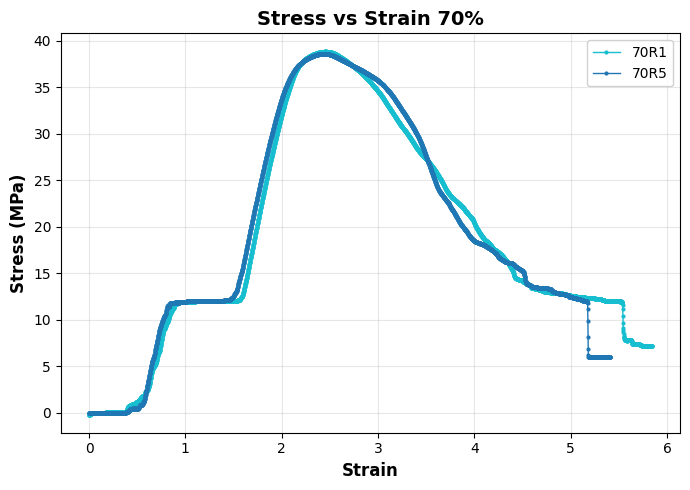

In [7]:
infill_rep1 = ['70R1','70R5']

def plot_combined(infill_rep1, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(7, 5))
    
    colors = plt.cm.tab10_r(np.linspace(0, 1, len(infill_rep1)))
    
    for idx, specimen_id in enumerate(infill_rep1):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna()
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=1, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain 70%', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_combined(infill_rep1, df)

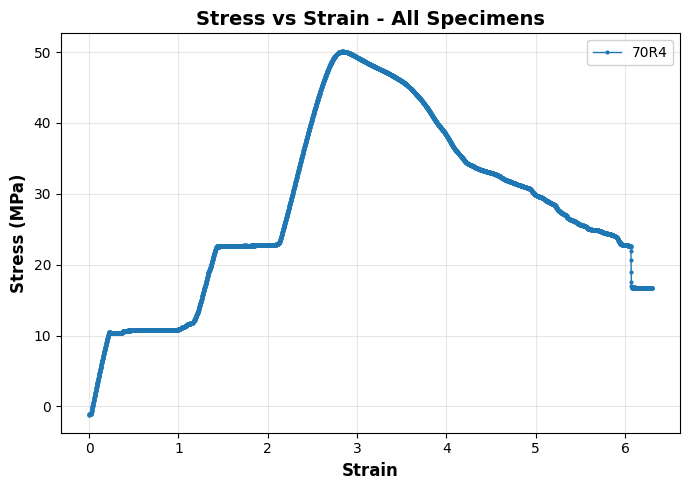

In [8]:
infill_rep1 = ['70R4']

def plot_combined(infill_rep1, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(7, 5))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_rep1)))
    
    for idx, specimen_id in enumerate(infill_rep1):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna()
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=1, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_combined(infill_rep1, df)

In [9]:
infill_den10 = ['10R1', '10R2', '10R3', '10R4', '10R5', '10R6', '10R7', '10R8', '10R9', '10R10']

def plot_combined(infill_den10, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_den10)))
    
    for idx, specimen_id in enumerate(infill_den10):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna()
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=1, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_combined(infill_den10, df)

KeyError: '10R1'

<Figure size 1200x700 with 0 Axes>

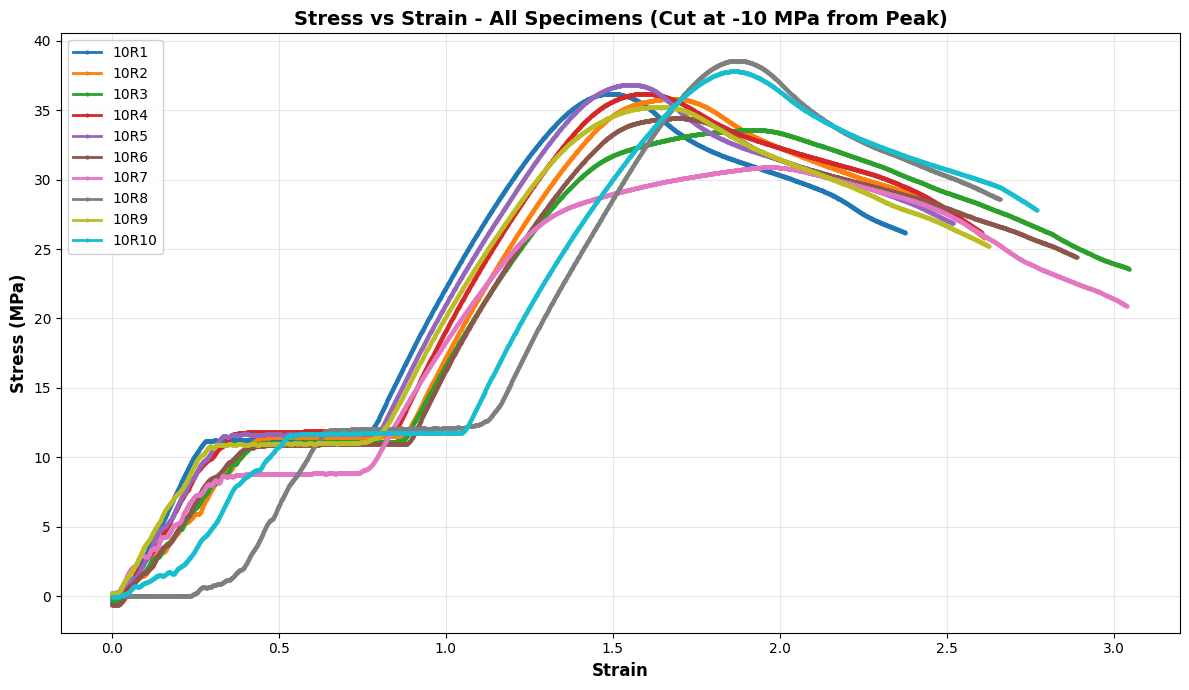

In [ ]:
def plot_combined(infill_den10, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_den10)))
    
    for idx, specimen_id in enumerate(infill_den10):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna().reset_index(drop=True)
        
        # Find the peak stress
        max_stress = specimen_data['Stress'].max()
        max_index = specimen_data['Stress'].idxmax()
        
        # Find where stress drops by 10 MPa from peak
        threshold = max_stress - 10
        # Look for the first point after peak where stress drops below threshold
        drop_indices = specimen_data[max_index:][specimen_data[max_index:]['Stress'] < threshold].index
        
        if len(drop_indices) > 0:
            cut_index = drop_indices[0]
            specimen_data = specimen_data[:cut_index]
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=2, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens (Cut at -10 MPa from Peak)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('stress_strain_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function with your dataframe
plot_combined(infill_den10, df)

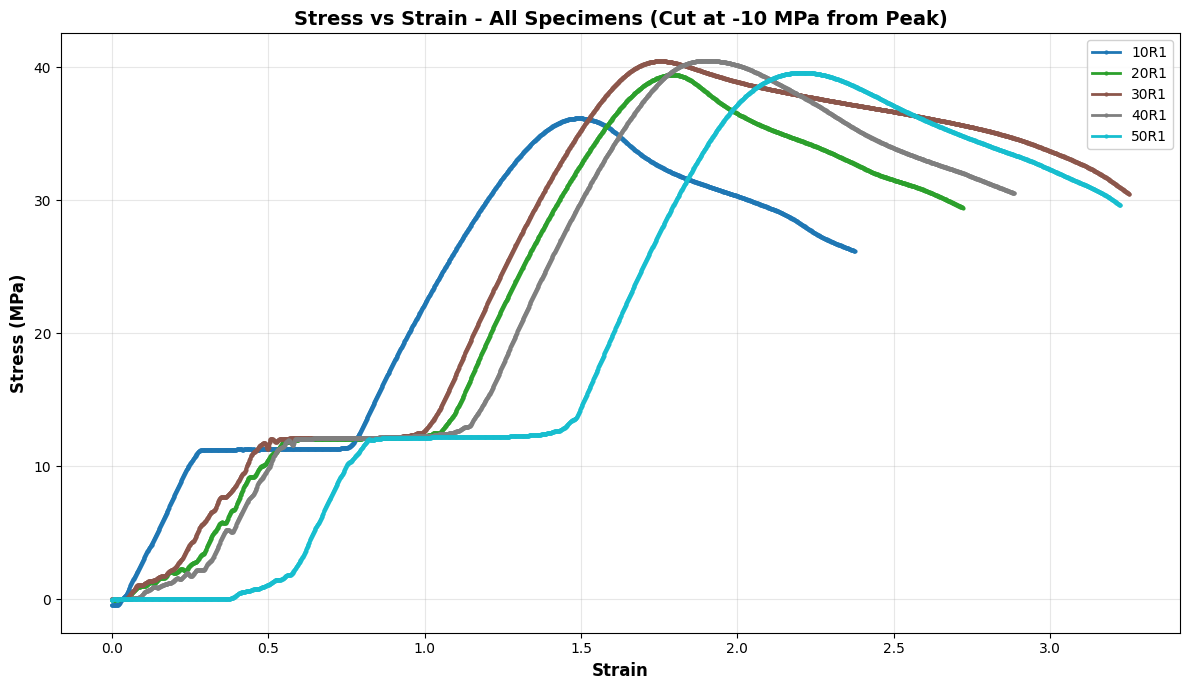

In [ ]:
def plot_combined(infill_rep1, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_rep1)))
    
    for idx, specimen_id in enumerate(infill_rep1):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna().reset_index(drop=True)
        
        # Find the peak stress
        max_stress = specimen_data['Stress'].max()
        max_index = specimen_data['Stress'].idxmax()
        
        # Find where stress drops by 10 MPa from peak
        threshold = max_stress - 10
        # Look for the first point after peak where stress drops below threshold
        drop_indices = specimen_data[max_index:][specimen_data[max_index:]['Stress'] < threshold].index
        
        if len(drop_indices) > 0:
            cut_index = drop_indices[0]
            specimen_data = specimen_data[:cut_index] 
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=2, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens (Cut at -10 MPa from Peak)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('stress_strain_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function with your dataframe
plot_combined(infill_rep1, df)